# Simplex Tabela Sergio

In [13]:
from fractions import Fraction

def to_frac_matrix(mat):
    return [[Fraction(x) for x in row] for row in mat]

def simplex_tableau_min_frac(A, b, c, I0=None, max_iter=50):
    """
    Simplex-tabela (minimização) JÁ na forma-padrão.
    NÃO adiciona novas folgas: considera que as colunas de I0 são a base inicial.
    Se I0 não for fornecido, usa as últimas m colunas de A.
    """
    m, n = len(A), len(A[0])          # m eq., n variáveis (incluindo folgas)
    A = to_frac_matrix(A)
    b = [Fraction(x) for x in b]
    c = [Fraction(x) for x in c]

    # Definição da base inicial
    if I0 is None:
        I0 = list(range(n - m, n))  # base padrão: últimas m colunas
    base_indices = I0[:]            # cópia explícita

    # ★ tableau (m+1) × (n+1)
    T = [[Fraction(0) for _ in range(n + 1)] for _ in range(m+1)]

    # linha-custo
    for j in range(n):
        T[0][j] = -c[j]

    # restrições
    for i in range(m):
        T[i+1][:n] = A[i]
        T[i+1][-1] = b[i]

    var  = [f"x{j+1}" for j in range(n)]
    base = [var[j] for j in base_indices]  # nomes das variáveis básicas

    def print_tableau(it_):
        head = ["  "] + var + ["LD"]
        print(f"\n── Tabela – iteração {it_} ──")
        print(" | ".join(f"{h:>8}" for h in head))
        print("-" * (12*(len(var)+2)))
        for i, row in enumerate(T):
            tag = "z" if i == 0 else base[i-1]
            print(f"{tag:>2} | " + " | ".join(f"{str(x):>8}" for x in row))

    print_tableau(0)

    for it in range(1, max_iter+1):
        # 1. escolhe coluna que entra
        enter_col, best = None, Fraction(0)
        for j in range(n):
            if T[0][j] > 0 and T[0][j] > best:
                best, enter_col = T[0][j], j

        if enter_col is None:
            print("\n*** ÓTIMO ALCANÇADO ***")
            print("\n⇒ Solução ótima (frações):")
            for j, val in enumerate(T[0][:-1], 1):
                print(f"x{j} = {val}")
            print("z* =", T[0][-1])
            break

        yk = [T[i][enter_col] for i in range(1, m+1)]
        print(f"\n♦ Iteração {it}")
        print(f"  k  (entra) : {var[enter_col]}")
        print(f"  y_k        : {[str(v) for v in yk]}")

        # 2. escolhe linha que sai
        pivot_row, min_ratio = None, None
        for i in range(1, m+1):
            col_val = T[i][enter_col]
            if col_val > 0:
                ratio = T[i][-1] / col_val
                if pivot_row is None or ratio < min_ratio:
                    pivot_row, min_ratio = i, ratio
        if pivot_row is None:
            raise ValueError("Problema ilimitado")

        print(f"  r  (sai)   : {base[pivot_row-1]}")
        print(f"  razão min  : {min_ratio}\n")

        # 3. pivoteamento
        piv = T[pivot_row][enter_col]
        T[pivot_row] = [x / piv for x in T[pivot_row]]
        for i in range(m+1):
            if i == pivot_row:
                continue
            factor = T[i][enter_col]
            T[i] = [x - factor*y for x, y in zip(T[i], T[pivot_row])]

        # 4. atualiza base
        base[pivot_row-1] = var[enter_col]
        print_tableau(it)

    else:
        raise RuntimeError("Limite de iterações atingido")

    # solução
    x = [Fraction(0) for _ in range(n)]
    for i, bv in enumerate(base):
        x[var.index(bv)] = T[i+1][-1]
    z = T[0][-1]
    return x, z

# Simplex Algoritmo Cruzeiro

In [16]:
import sympy as sp

def simplex_standard_form(A, b, c, I0, max_iter=50, verbose=True):
    flat = lambda M: [M[i] for i in range(M.rows * M.cols)]

    A = sp.Matrix(A)
    b = sp.Matrix(b).reshape(len(b), 1)
    c = sp.Matrix(c).reshape(1, len(c))

    m, n = A.shape
    I = list(I0)

    for it in range(1, max_iter + 1):
        # Passo 1
        B      = A[:, I]
        B_inv  = B.inv()
        x_B    = B_inv * b
        if any(xi < 0 for xi in flat(x_B)):
            raise ValueError("Base não factível (x_B < 0).")

        # Passo 2
        λT   = c[:, I] * B_inv           # já é λᵀ
        N    = [j for j in range(n) if j not in I]
        ĉ_N  = c[:, N] - λT * A[:, N]

        # Teste de ótima
        if all(val >= 0 for val in ĉ_N.tolist()[0]):
            if verbose:
                print(f"\n✓ Iteração {it}: solução ótima.")
                print(f"Básicas I  : {[i+1 for i in I]}")
                print(f"Não-básicas: {[j+1 for j in N]}")
                print("B =");      sp.pprint(B)                # ① B
                print("Bᵀ =");      sp.pprint(B.T)              # ① B transposto
                print("λᵀ =", list(map(sp.nsimplify, λT)))      # ② λ transposto
                print("x_Bᵗ =", list(map(sp.nsimplify, x_B)))
                print("ĉ_N =", list(map(sp.nsimplify, ĉ_N)))
               # print("Valor atual da função objetivo (custo) z = ", (c * x_B)[0])
               # print("Base ótima I* =", [i+1 for i in I])
               # print("Variáveis básicas x* = ", [x_B[i, 0] for i in range(m)])

            break

        # Escolha de k
        j_star = min(range(len(N)), key=lambda j: ĉ_N[0, j])
        k      = N[j_star]

        # Direção
        y = B_inv * A[:, k]

        # Ilimitado?
        if all(yi <= 0 for yi in flat(y)):
            raise ValueError("Problema ilimitado (y ≤ 0).")

        β       = [x_B[i, 0] / y[i, 0] if y[i, 0] > 0 else sp.oo for i in range(m)]
        l_star  = min(range(m), key=lambda i: β[i])
        I[l_star] = k                      # troca na base

        # ─────── LOG detalhado ──────────────────────────────
        if verbose:
            print("\n" + "━"*55)
            print(f"Iteração {it}")
            print(f"Básicas I  : {[i+1 for i in I]}")
            print(f"Não-básicas: {[j+1 for j in N]}")
            print("B =");      sp.pprint(B)                # ① B
            print("Bᵀ =");      sp.pprint(B.T)              # ① B transposto
            print("λᵀ =", list(map(sp.nsimplify, λT)))      # ② λ transposto
            print("x_Bᵗ =", list(map(sp.nsimplify, x_B)))
            print("ĉ_N =", list(map(sp.nsimplify, ĉ_N)))
            print(f"→ Entra  x_{k+1}")
            print("yᵗ  =", list(map(sp.nsimplify, y)))
            print("β   =", [sp.nsimplify(r) for r in β])
            print(f"← Sai   linha {l_star+1}")

    else:
        raise RuntimeError("Limite de iterações atingido.")

    # Solução final
    x = sp.zeros(n, 1)
    B  = A[:, I]
    x_B = B.inv() * b
    for row_idx, var_idx in enumerate(I):
        x[var_idx, 0] = x_B[row_idx, 0]
    z = (c * x)[0]
    print("\n═══════ SOLUÇÃO FINAL ═══════")
    sp.pprint(sp.Matrix.hstack(sp.Matrix([[sp.Symbol('x*')]]), x.T))
    print("z* =", z)
    print("Base ótima I* =", [i+1 for i in I])
    print("Variáveis básicas x* =", [x[i, 0] for i in range(n)])
    return x, z, I


# Solução Gráfica

In [7]:
import numpy as np
import matplotlib.pyplot as plt

def plot_feasible_region(constraints,
                         x1_range=(0, 10),
                         x2_range=(0, 10),
                         resolution=400,
                         fill_region=True,
                         show_labels=True):
    """
    Desenha a região viável para um sistema de inequações lineares em x1 e x2.

    Parameters
    ----------
    constraints : list[dict]
        Cada dicionário descreve uma desigualdade do tipo
            a1 * x1 + a2 * x2  op  b
        Campos obrigatórios:
            'a1', 'a2', 'b' : coeficientes numéricos
            'op'            : '<=' ou '>='
        Campos opcionais:
            'color'         : cor da reta
            'label'         : texto exibido no gráfico
    x1_range, x2_range : tuple(float, float)
        Limites dos eixos x1 e x2.
    resolution : int
        Número de pontos da malha.
    fill_region : bool
        Se True, preenche a região viável.
    show_labels : bool
        Se True, escreve os rótulos das restrições.
    """

    # Geração da malha
    x1_vals = np.linspace(*x1_range, resolution)
    x2_vals = np.linspace(*x2_range, resolution)
    X1, X2 = np.meshgrid(x1_vals, x2_vals)

    feasible = np.ones_like(X1, dtype=bool)

    # Setup gráfico
    fig, ax = plt.subplots(figsize=(8, 6))
    default_colors = plt.rcParams['axes.prop_cycle'].by_key()['color']

    for idx, c in enumerate(constraints):
        a1, a2, b, op = c['a1'], c['a2'], c['b'], c['op']
        color = c.get('color', default_colors[idx % len(default_colors)])
        label = c.get('label', f'{a1}x₁ + {a2}x₂ {op} {b}')

        # Corrige \le e \ge para matplotlib
        label = label.replace(r'\le', r'\leq').replace(r'\ge', r'\geq')

        # Atualiza região viável
        expr = a1 * X1 + a2 * X2
        if op == '<=':
            feasible &= (expr <= b + 1e-9)
        elif op == '>=':
            feasible &= (expr >= b - 1e-9)
        else:
            raise ValueError("op deve ser '<=' ou '>='")

        # Plota linha de fronteira
        if np.isclose(a2, 0):  # linha vertical
            x_const = b / a1
            ax.axvline(x_const, color=color)
            if show_labels:
                ax.text(x_const + 0.1, 0.05*(x2_range[1]-x2_range[0]),
                        label, color=color, rotation=90, va='bottom')
        else:
            y_line = (b - a1 * x1_vals) / a2
            ax.plot(x1_vals, y_line, color=color)
            if show_labels:
                x_mid = (x1_range[0] + x1_range[1]) / 4
                y_mid = (b - a1 * x_mid) / a2
                ax.text(x_mid, y_mid + 0.3, label, color=color)

    # Condições x1 >= 0, x2 >= 0
    ax.axhline(0, color='black')
    ax.axvline(0, color='black')
    feasible &= (X1 >= 0) & (X2 >= 0)

    if fill_region:
        ax.contourf(X1, X2, feasible, levels=[0.5, 1], colors=['#D3D3D3'])

    # Ajustes finais
    ax.set_xlim(x1_range)
    ax.set_ylim(x2_range)
    ax.set_xlabel('$x_1$')
    ax.set_ylabel('$x_2$')
    ax.set_title('Região Viável')
    ax.grid(True)
    ax.legend()
    plt.show()

Exemplo simplex tabela

In [ ]:
A = [
    [2, 1, 1, 0, 0],
    [1, 2, 0, 1, 0],
    [0, 1, 0, 0, 1]
]
b = [8, 7, 3]
c = [-1, -1, 0, 0, 0]

I0 = [2, 3, 4]  # base explícita: x3, x4, x5
x_opt, z_opt = simplex_tableau_min_frac(A, b, c, I0)


Exemplo Simplex Algoritmo

In [ ]:
A = [[1,7,4,1,0,0],
    [2,1,7,0,1,0],
    [8,4,1,0,0,1]]
b = [100,100,100]
c = [-4,-4,-7,0,0,0]
I0 = [3,4,5]

x_star, z_star, I_star = simplex_standard_form(A,b,c,I0)

Exemplo Solução Gráfica

/tmp/ipykernel_48166/1669792645.py:92: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


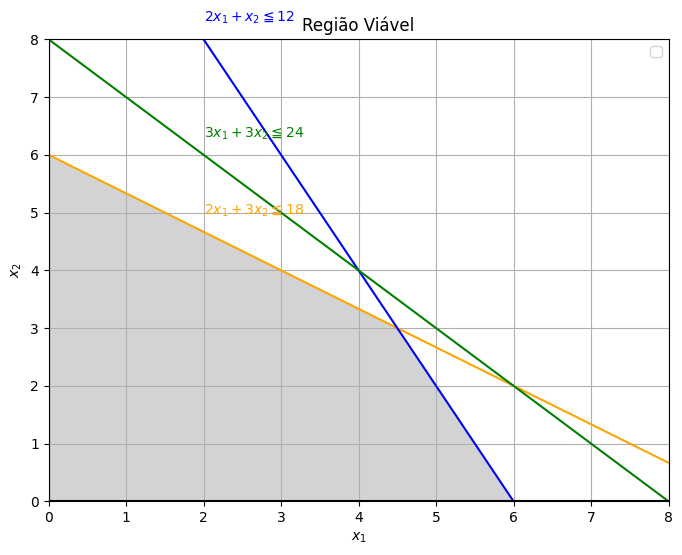

In [19]:
constraints_example = [
        {'a1': 2, 'a2': 3, 'b': 18, 'op': '<=',
         'color': 'orange', 'label': r'$2x_1 + 3x_2 \leq 18$'},
        {'a1': 2, 'a2': 1, 'b': 12, 'op': '<=',
         'color': 'blue',   'label': r'$2x_1 + x_2 \leq 12$'},
        {'a1': 3, 'a2': 3, 'b': 24, 'op': '<=',
         'color': 'green',  'label': r'$3x_1 + 3x_2 \leq 24$'}
    ]

plot_feasible_region(constraints_example,
                        x1_range=(0, 8),
                        x2_range=(0, 8))